1. Load Data

In [2]:
import pandas as pd

df = pd.read_csv(
    '../data/processed/scored_outfits.csv'
)

df.head()

,top_type,top_color,top_usage,top_season,bottom_type,bottom_color,bottom_usage,bottom_season,shoe_type,shoe_color,shoe_usage,shoe_season,compatibility_score,compatibility_label
0,Tshirts,Grey,Sports,Summer,Shorts,Blue,Casual,Summer,Casual Shoes,White,Casual,Fall,47,Poor Match
1,Tshirts,Blue,Casual,Fall,Jeans,Blue,Casual,Summer,Sports Shoes,Blue,Sports,Summer,40,Poor Match
2,Tshirts,Green,Sports,Fall,Jeans,Blue,Casual,Summer,Sports Shoes,Black,Sports,Summer,39,Poor Match
3,Tshirts,Black,Sports,Fall,Track Pants,Navy Blue,Sports,Summer,Casual Shoes,Blue,Casual,Fall,47,Poor Match
4,Tshirts,Green,Sports,Fall,Track Pants,Black,Sports,Fall,Casual Shoes,Blue,Casual,Fall,47,Poor Match


2. Prepare Features

In [3]:
X = df.drop(
    columns=['compatibility_score',
             'compatibility_label']
)

y = df['compatibility_score']

3. Encode Categorical Columns

In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoders = {}

for col in X.columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    encoders[col] = le

In [6]:
X.head()

,top_type,top_color,top_usage,top_season,bottom_type,bottom_color,bottom_usage,bottom_season,shoe_type,shoe_color,shoe_usage,shoe_season
0,4,6,3,1,1,2,0,2,0,11,0,0
1,4,1,0,0,0,2,0,2,2,2,2,2
2,4,5,3,0,0,2,0,2,2,1,2,2
3,4,0,3,0,2,10,2,2,0,2,0,0
4,4,5,3,0,2,1,2,0,0,2,0,0


4. Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 5: Train Model 

In [9]:
from sklearn.ensemble import RandomForestRegressor

In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [11]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

6. Predictions

In [12]:
preds = rf.predict(X_test)

7. Evaluations

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [14]:
mae = mean_absolute_error(
    y_test,
    preds
)

rmse = mean_squared_error(
    y_test,
    preds
) ** 0.5

r2 = r2_score(
    y_test,
    preds
)

In [15]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 5.289513967652718
RMSE: 6.919984796859994
R2  : 0.8273542016989299


8. Feature Importance

In [16]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

In [17]:
importance.sort_values(
    by='importance',
    ascending=False
).head(10)

,feature,importance
10,shoe_usage,0.183513
1,top_color,0.176218
6,bottom_usage,0.175318
2,top_usage,0.118815
5,bottom_color,0.118638
11,shoe_season,0.050691
9,shoe_color,0.039831
4,bottom_type,0.036582
7,bottom_season,0.035425
0,top_type,0.031676


9. Model Comparison

Train the model

In [18]:
from sklearn.linear_model import LinearRegression

Linear regression evaluation

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(
    y_test,
    lr_preds
)

lr_rmse = (
    mean_squared_error(
        y_test,
        lr_preds
    ) ** 0.5
)

lr_r2 = r2_score(
    y_test,
    lr_preds
)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression Results
MAE : 10.680421513840193
RMSE: 13.369872205155321
R2  : 0.35553365178878205


Model comparison table

In [22]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        lr_mae,
        mae
    ],
    'RMSE': [
        lr_rmse,
        rmse
    ],
    'R2': [
        lr_r2,
        r2
    ]
})

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,10.680422,13.369872,0.355534
1,Random Forest,5.289514,6.919985,0.827354


Save the model

In [21]:
import joblib

joblib.dump(
    rf,
    '../models/random_forest.pkl'
)

['../models/random_forest.pkl']

In [32]:
joblib.dump(
    encoders,
    '../models/encoders.pkl'
)

['../models/encoders.pkl']

Checking files

Random forest

In [36]:
import joblib

rf_model = joblib.load(
    '../models/random_forest.pkl'
)

print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [37]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 200,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Encoders

In [38]:
encoders = joblib.load(
    '../models/encoders.pkl'
)

print(type(encoders))

<class 'dict'>


In [39]:
encoders.keys()

dict_keys(['top_type', 'top_color', 'top_usage', 'top_season', 'bottom_type', 'bottom_color', 'bottom_usage', 'bottom_season', 'shoe_type', 'shoe_color', 'shoe_usage', 'shoe_season'])

In [40]:
encoders['top_color'].classes_

array(['Black', 'Blue', 'Brown', 'Burgundy', 'Charcoal', 'Green', 'Grey',
       'Maroon', 'Navy Blue', 'Olive', 'Orange', 'Pink', 'Purple', 'Red',
       'White', 'Yellow'], dtype=object)

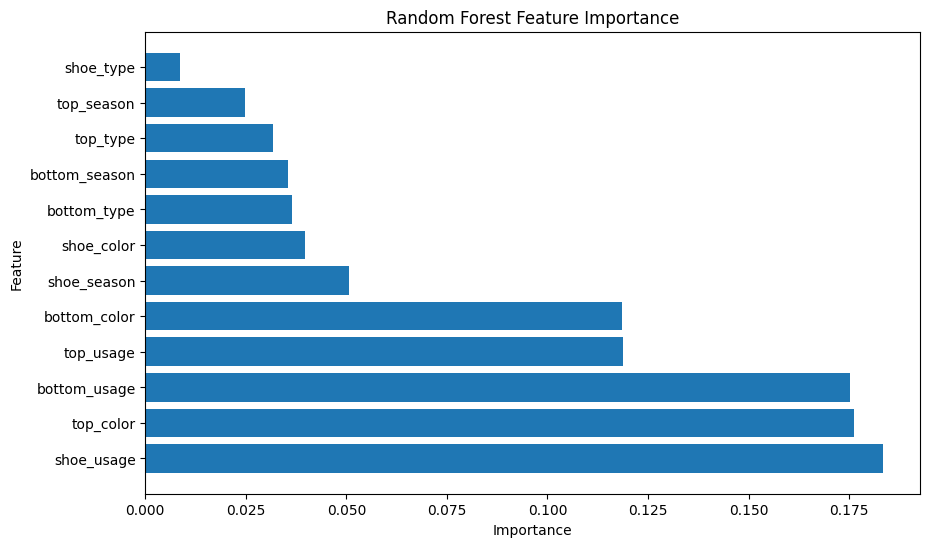

In [24]:
import matplotlib.pyplot as plt

feature_importance_df = importance.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['feature'],
    feature_importance_df['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.show()